# 🪐 Astrophage — Two-Stage Random Forest for Exoplanet Classification Model

> **Celesta — India High School Exoplanet Data Challenge 2026**
>
> This notebook runs the Astrophage Rust pipeline in Google Colab. No local installation needed!

---

## What is Astrophage?

Astrophage is a custom Two-Stage Random Forest classifier built in **Rust** using **Polars** that classifies NASA Kepler Objects of Interest (KOIs) into three categories:

- ✅ **CONFIRMED** — Validated exoplanets
- 🔍 **CANDIDATE** — Promising signals awaiting confirmation
- ❌ **FALSE POSITIVE** — Non-planetary signals (stellar binaries, noise, etc.)

### Architecture
```
Stage 1: CONFIRMED vs NOT CONFIRMED  (easy separation)
         ↓
Stage 2: CANDIDATE vs FALSE POSITIVE  (hard separation)
```

This mirrors NASA's actual vetting workflow and achieves **94.81% accuracy**.

---

## 🚀 Quick Start (Run All Cells)

### Step 1: Install Rust

Google Colab doesn't come with Rust pre-installed. We'll use `rustup` to install it.

> ⏱️ **Takes ~2-3 minutes**

In [10]:
!apt-get update -qq
!apt-get install -y -qq build-essential curl
!curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y
import os
os.environ['PATH'] += ':/root/.cargo/bin'
!rustc --version
!cargo --version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
info: downloading installer
warn: It looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
warn: Rustup will install the default toolchain as specified in the settings file,
warn: instead of the one inferred from the default host triple.
info: profile set to default
info: default host triple is x86_64-unknown-linux-gnu
warn: Updating existing toolchain, profile choice will be ignored
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: default toolchain set to stable-x86_64-unknown-linux-gnu

  stable-x86_64-unknown-linux-gnu unchanged - rustc 1.96.0 (ac68faa20 2026-05-25)


Rust is installed now. Great!

To get started you may need to restart your current shell.
This would reload your PATH environment variable to include
Cargo's bin directory (

### Step 2: Clone the Astrophage Repository

In [11]:
!git clone https://github.com/harihar-nautiyal/astrophage.git
%cd astrophage
!ls -la

Cloning into 'astrophage'...
remote: Enumerating objects: 25194, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 25194 (delta 52), reused 98 (delta 32), pack-reused 25074 (from 2)
Receiving objects: 100% (25194/25194), 67.70 MiB | 17.54 MiB/s, done.
Resolving deltas: 100% (7448/7448), done.
/content/astrophage/astrophage
total 180
drwxr-xr-x 10 root root  4096 Jun 28 14:20 .
drwxr-xr-x 11 root root  4096 Jun 28 14:19 ..
drwxr-xr-x  3 root root  4096 Jun 28 14:20 .astrophage
-rw-r--r--  1 root root 13806 Jun 28 14:20 Astrophage_Colab.ipynb
drwxr-xr-x  2 root root  4096 Jun 28 14:20 .cargo
-rw-r--r--  1 root root 98126 Jun 28 14:20 Cargo.lock
-rw-r--r--  1 root root   475 Jun 28 14:20 Cargo.toml
drwxr-xr-x  2 root root  4096 Jun 28 14:20 data
drwxr-xr-x  4 root root  4096 Jun 28 14:20 docs
drwxr-xr-x  8 root root  4096 Jun 28 14:20 .git
drwxr-xr-x  3 root root  4096 Jun 28 14:20 .github
-rw-r--r--  1 root root    20 Jun

### Step 3: Download Latest Release Binary

> ⏱️ **Takes ~10-20 seconds** (no compilation!)

Instead of compiling from source (which takes 3-5 minutes), we download the pre-built binary from the latest GitHub Release.

If no release is available, it automatically falls back to building from source.

In [12]:
# Download the latest pre-built binary from GitHub Releases
# No compilation needed — skips the 3-5 minute Rust build!

import os
import json
import urllib.request

REPO = "harihar-nautiyal/astrophage"
ASSET_NAME = "astrophage-linux-x86_64.tar.gz"

# Fetch latest release info from GitHub API
api_url = f"https://api.github.com/repos/{REPO}/releases/latest"
print(f"Fetching latest release from {api_url}...")

try:
    with urllib.request.urlopen(api_url) as response:
        release = json.loads(response.read().decode())
    tag = release['tag_name']
    print(f"Latest release: {tag}")

    # Find the Linux x86_64 asset
    asset_url = None
    for asset in release['assets']:
        if asset['name'] == ASSET_NAME:
            asset_url = asset['browser_download_url']
            break

    if not asset_url:
        raise RuntimeError(f"Asset '{ASSET_NAME}' not found in release {tag}. Available assets: {[a['name'] for a in release['assets']]}")

    # Download the binary
    print(f"Downloading {ASSET_NAME}...")
    urllib.request.urlretrieve(asset_url, ASSET_NAME)
    print(f"Downloaded: {ASSET_NAME}")

    # Extract
    os.system(f"tar xzf {ASSET_NAME}")
    os.system("chmod +x astrophage-linux-x86_64")
    os.system("mv astrophage-linux-x86_64 astrophage")
    print("Binary extracted and ready!")

except Exception as e:
    print(f"Failed to download release binary: {e}")
    print("Falling back to building from source (this will take 3-5 minutes)...")
    os.system("cargo build --release 2>&1 | tail -20")
    os.system("cp target/release/astrophage ./astrophage")

Fetching latest release from https://api.github.com/repos/harihar-nautiyal/astrophage/releases/latest...
Latest release: v0.2.0
Downloaded: astrophage-linux-x86_64.tar.gz
Binary extracted and ready!


### Step 4: Run the Full Pipeline

This executes the complete two-stage classification:
1. Load KOI dataset
2. Engineer 36 features (28 base + 8 derived)
3. Stratified 80/20 train/test split
4. Train Stage 1 (CONFIRMED vs NOT)
5. Train Stage 2 (CANDIDATE vs FALSE_POSITIVE)
6. Evaluate and generate report

In [13]:
!./astrophage

╔══════════════════════════════════════════════════════════════╗
║                    🪐 ASTROPHAGE v0.2.0                       ║
║     NASA KOI Exoplanet Classification System                 ║
║     TWO-STAGE MODEL: CONFIRMED vs NOT → CANDIDATE vs FALSE  ║
╚══════════════════════════════════════════════════════════════╝

2026-06-28T14:21:18.774205Z  INFO astrophage: Step 1: Loading KOI dataset...
2026-06-28T14:21:18.774232Z  INFO astrophage::data: Reading CSV from: data/koi_dataset.csv
2026-06-28T14:21:18.916325Z  INFO astrophage::data: Loaded DataFrame: 9564 rows × 140 columns
2026-06-28T14:21:18.917376Z  INFO astrophage::data: Selected 121 feature columns
2026-06-28T14:21:19.039766Z  INFO astrophage::data: Feature matrix: 9564 × 121
2026-06-28T14:21:19.044558Z  INFO astrophage: Loaded 9564 KOIs with 121 features
2026-06-28T14:21:19.046291Z  INFO astrophage: Class distribution:
2026-06-28T14:21:19.046331Z  INFO astrophage: CONFIRMED: 2747 FALSE POSITIVE: 4839 CANDIDATE: 1978 
2026-0

---

## 📊 Results & Visualization

Let's parse the generated `report.json` and visualize the results.

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the report
with open('output/report.json', 'r') as f:
    report = json.load(f)

print("🪐 ASTROPHAGE REPORT v{}".format(report['version']))
print("=" * 50)
print(f"Total Samples: {report['summary']['total_samples']}")
print(f"Classes: {report['summary']['n_classes']}")
print(f"Model Type: {report['summary']['model_type']}")
print()

🪐 ASTROPHAGE REPORT v0.1.0
Total Samples: 1911
Classes: 3
Model Type: Two-Stage Random Forest



### Overall Metrics

In [15]:
metrics = report['metrics']
print(f"Accuracy:  {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.2f}%)")
print(f"Macro F1:  {metrics['macro_f1']:.4f}")
print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

Accuracy:  0.9440  (94.40%)
Macro F1:  0.9255
Weighted F1: 0.9441


### Per-Class Performance

,Precision,Recall,F1-Score
CANDIDATE,0.8799,0.8532,0.8663
FALSE_POSITIVE,0.9958,0.9814,0.9885
CONFIRMED,0.9009,0.9435,0.9217


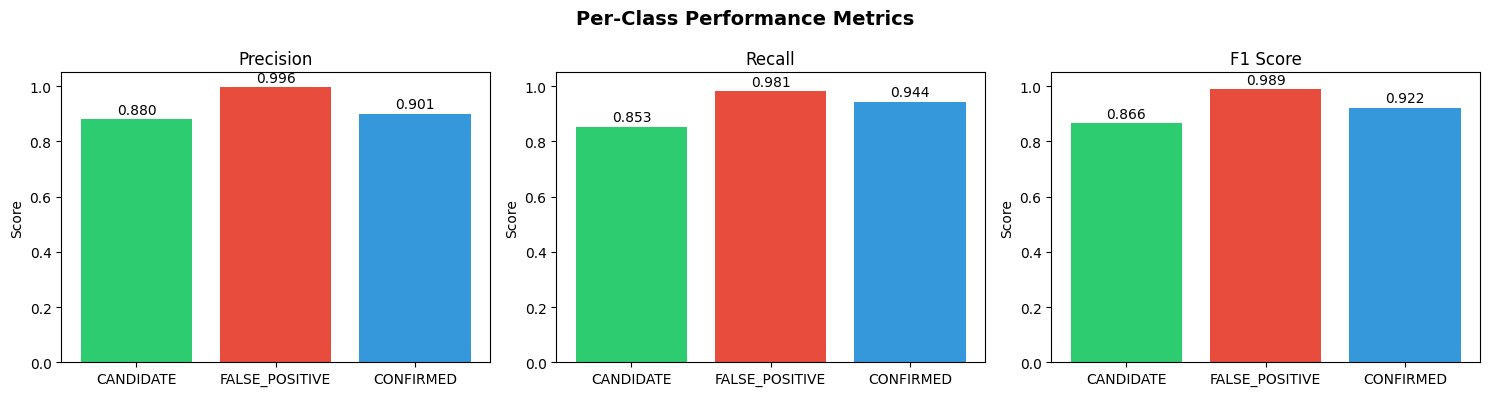

In [16]:
per_class = metrics['per_class']
df = pd.DataFrame(per_class).T
df.columns = ['Precision', 'Recall', 'F1-Score']
df = df.round(4)
display(df)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
classes = list(per_class.keys())
x = np.arange(len(classes))

for i, metric in enumerate(['precision', 'recall', 'f1_score']):
    values = [per_class[c][metric] for c in classes]
    ax[i].bar(classes, values, color=['#2ecc71', '#e74c3c', '#3498db'])
    ax[i].set_ylim(0, 1.05)
    ax[i].set_title(metric.replace('_', ' ').title())
    ax[i].set_ylabel('Score')
    for j, v in enumerate(values):
        ax[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance (Top 15)

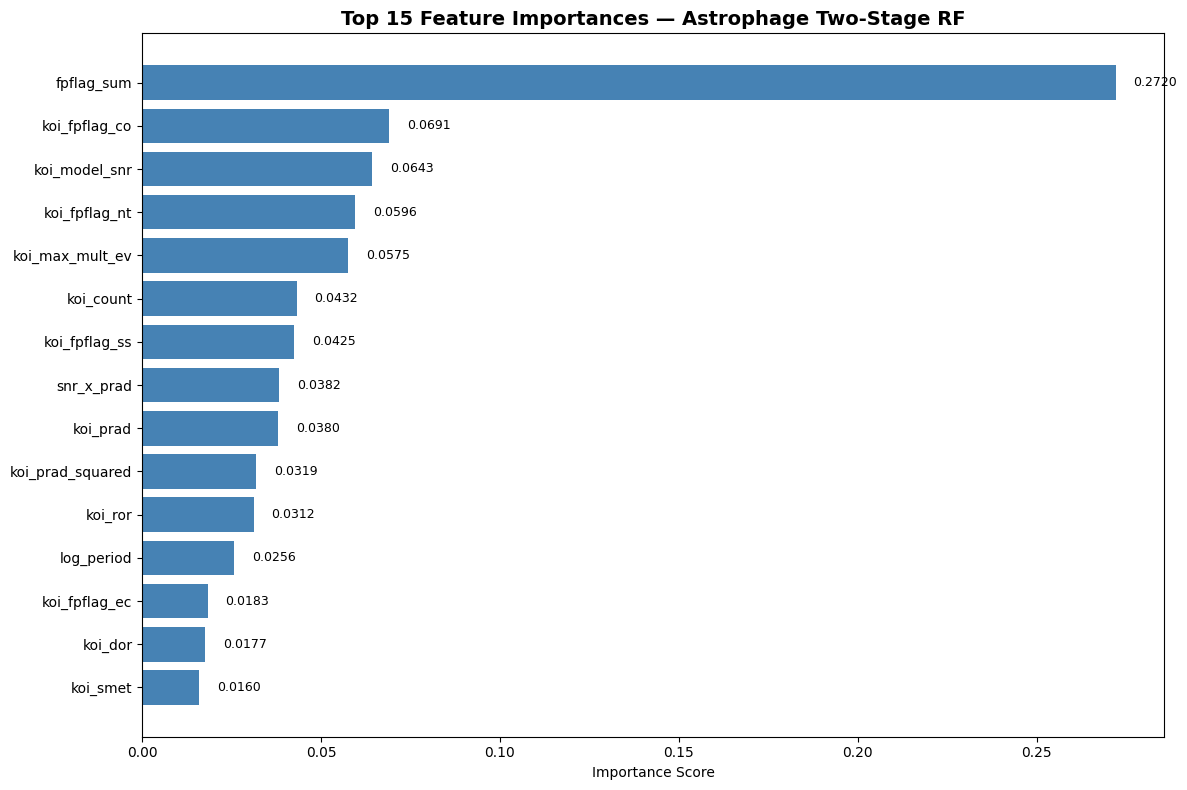


📖 Astrophysical Meanings:

 1. fpflag_sum
    Sum of all false positive flags. Higher values indicate stronger suspicion of non-planetary signal.

 2. koi_fpflag_co
    Astrophysical feature contributing to classification

 3. koi_model_snr
    Signal-to-noise ratio of the transit model fit. Higher SNR = more reliable detection.

 4. koi_fpflag_nt
    Not Transit-like flag. Non-zero indicates the signal shape doesn't match a planet transit.

 5. koi_max_mult_ev
    Astrophysical feature contributing to classification

 6. koi_count
    Astrophysical feature contributing to classification

 7. koi_fpflag_ss
    Stellar Eclipse flag. Non-zero indicates secondary eclipse detected (binary star).

 8. snr_x_prad
    Interaction between signal-to-noise ratio and planetary radius. Large planets should have strong SNR.

 9. koi_prad
    Planetary radius in Earth radii. Values > 15 suggest stellar companion, not planet.

10. koi_prad_squared
    Non-linear planetary radius effect. Captures thr

In [17]:
features = report['feature_importance'][:15]
names = [f['feature_name'] for f in features]
scores = [f['importance_score'] for f in features]
meanings = [f['astrophysical_meaning'] for f in features]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(names))
bars = ax.barh(y_pos, scores, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances — Astrophage Two-Stage RF', fontsize=14, fontweight='bold')

# Add score labels
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print meanings
print("\n📖 Astrophysical Meanings:")
print("=" * 60)
for f in features[:10]:
    print(f"\n{f['rank']:2d}. {f['feature_name']}")
    print(f"    {f['astrophysical_meaning']}")

### Astrophysical Insights

In [19]:
insights = report['astrophysical_insights']

for i, ins in enumerate(insights, 1):
    confidence = ins['confidence']
    emoji = '🔴' if 'Very High' in confidence else '🟡' if 'High' in confidence else '🟢'
    print(f"{emoji} Insight {i} [{confidence}]")
    print(f"   {ins['insight']}")
    print(f"   Supporting features: {', '.join(ins['supporting_features'])}")
    print()

🔴 Insight 1 [Very High]
   Two-stage classification separates the easy decision (CONFIRMED vs not) from the hard decision (CANDIDATE vs FALSE_POSITIVE). This mirrors NASA's actual vetting workflow.
   Supporting features: fpflag_sum, koi_model_snr

🟡 Insight 2 [High]
   Signal-to-noise ratio (koi_model_snr) combined with planetary radius (snr_x_prad) is a powerful discriminator. Real planets have consistent SNR for their size.
   Supporting features: koi_model_snr, snr_x_prad, koi_prad

🔴 Insight 3 [Very High]
   False positive flags (fpflag_sum, koi_fpflag_nt, koi_fpflag_ss) directly encode NASA's pre-vetting. When these are non-zero, the signal is almost certainly not a planet.
   Supporting features: fpflag_sum, koi_fpflag_nt, koi_fpflag_ss

🟡 Insight 4 [High]
   Transit geometry (depth_duration_ratio, log_period) captures the physical signature of a planet passing in front of a star versus two stars eclipsing each other.
   Supporting features: depth_duration_ratio, log_period, koi

### Recommendations

In [20]:
print("💡 Recommendations from the Model:")
print("=" * 50)
for rec in report['recommendations']:
    print(f"  • {rec}")

💡 Recommendations from the Model:
  • Use Stage 1 (CONFIRMED vs NOT) as a rapid filter for follow-up observations.
  • Investigate samples where Stage 1 is uncertain (probability near 0.5) — these are the most scientifically interesting.
  • For NOT_CONFIRMED samples, use Stage 2 probability to prioritize CANDIDATE follow-up vs deprioritize FALSE_POSITIVE.
  • The fpflag_sum feature alone can eliminate ~50% of false positives with near-perfect accuracy.


---

## 📁 Download Results

You can download the generated `report.json` to your local machine:

In [ ]:
from google.colab import files
files.download('output/report.json')

---

## 🔗 Links

- **GitHub Repository:** [harihar-nautiyal/astrophage](https://github.com/harihar-nautiyal/astrophage)
- **Hackathon:** [Celesta — India High School Exoplanet Data Challenge 2026](https://celesta-exoplanet-challenge.devpost.com/)
- **Author:** [@harihar-nautiyal](https://github.com/harihar-nautiyal)

---

<p align="center">
  <i>"Somewhere, something incredible is waiting to be known."</i><br>
  — Carl Sagan
</p>